In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore", category=FutureWarning)

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s", datefmt="%H:%M:%S")

import numpy as np
import pandas as pd

from src.ml.data import get_train_val_test_splits
from src.ml.multiclass import train, evaluate, format_per_class_summary, save_model

splits = get_train_val_test_splits(sample_per_family=25_000)

X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]["attack_family_denorm"]
y_val   = splits["y_val"]["attack_family_denorm"]
y_test  = splits["y_test"]["attack_family_denorm"]

print(f"Train: {X_train.shape}, classes: {y_train.unique()}")
print(f"Class counts in training set:")
print(y_train.value_counts())

20:49:36 | Loading labeled events (≤25000/family)
20:50:35 | Loaded 118,028 labeled rows
20:50:35 | Class distribution: {'Benign': 25000, 'DoS': 25000, 'DDoS': 25000, 'Reconnaissance': 25000, 'Brute Force': 13835, 'Web Attack': 2180, 'Botnet': 1966, 'Infiltration': 36, 'Exploit': 11}
20:50:36 | Splits: train=82,619, val=11,803, test=23,606


Train: (82619, 76), classes: ['Brute Force' 'DDoS' 'DoS' 'Reconnaissance' 'Benign' 'Web Attack'
 'Botnet' 'Infiltration' 'Exploit']
Class counts in training set:
attack_family_denorm
DDoS              17500
Reconnaissance    17500
DoS               17500
Benign            17500
Brute Force        9684
Web Attack         1526
Botnet             1376
Infiltration         25
Exploit               8
Name: count, dtype: int64


In [2]:
model, le = train(X_train, y_train, X_val, y_val)

print(f"\nModel ready. Classes ordered: {list(le.classes_)}")

20:50:46 | Label encoding map:
20:50:46 |   0 → Benign
20:50:46 |   1 → Botnet
20:50:46 |   2 → Brute Force
20:50:46 |   3 → DDoS
20:50:46 |   4 → DoS
20:50:46 |   5 → Exploit
20:50:46 |   6 → Infiltration
20:50:46 |   7 → Reconnaissance
20:50:46 |   8 → Web Attack
20:50:46 | Class weights (higher = rarer class):
20:50:46 |   Class 0: n=17,500  weight=0.5246
20:50:46 |   Class 1: n= 1,376  weight=6.6714
20:50:46 |   Class 2: n= 9,684  weight=0.9479
20:50:46 |   Class 3: n=17,500  weight=0.5246
20:50:46 |   Class 4: n=17,500  weight=0.5246
20:50:46 |   Class 5: n=     8  weight=1147.4861
20:50:46 |   Class 6: n=    25  weight=367.1956
20:50:46 |   Class 7: n=17,500  weight=0.5246
20:50:46 |   Class 8: n= 1,526  weight=6.0157
20:50:46 | Training XGBoost (9 classes, 82,619 rows)
20:51:07 |   Trained in 20.8s



Model ready. Classes ordered: ['Benign', 'Botnet', 'Brute Force', 'DDoS', 'DoS', 'Exploit', 'Infiltration', 'Reconnaissance', 'Web Attack']


In [3]:
val_metrics = evaluate(model, le, X_val, y_val, "XGBoost (Validation)")

print("=== VALIDATION RESULTS ===")
print(f"  Accuracy:        {val_metrics['accuracy']}")
print(f"  Macro Precision: {val_metrics['macro_precision']}")
print(f"  Macro Recall:    {val_metrics['macro_recall']}")
print(f"  Macro F1:        {val_metrics['macro_f1']}")
print(f"  Prediction time: {val_metrics['pred_time_sec']}s")

print("\n=== PER-CLASS PERFORMANCE (Validation) ===")
print(format_per_class_summary(val_metrics).to_string(index=False))

=== VALIDATION RESULTS ===
  Accuracy:        0.9985
  Macro Precision: 0.974
  Macro Recall:    0.9982
  Macro F1:        0.9849
  Prediction time: 0.18s

=== PER-CLASS PERFORMANCE (Validation) ===
         Class  Support  Precision  Recall     F1
        Benign     2500     0.9976  0.9972 0.9974
           DoS     2500     0.9980  0.9980 0.9980
          DDoS     2500     1.0000  1.0000 1.0000
Reconnaissance     2500     1.0000  0.9996 0.9998
   Brute Force     1384     1.0000  0.9978 0.9989
    Web Attack      218     0.9908  0.9908 0.9908
        Botnet      196     0.9800  1.0000 0.9899
  Infiltration        4     0.8000  1.0000 0.8889
       Exploit        1     1.0000  1.0000 1.0000


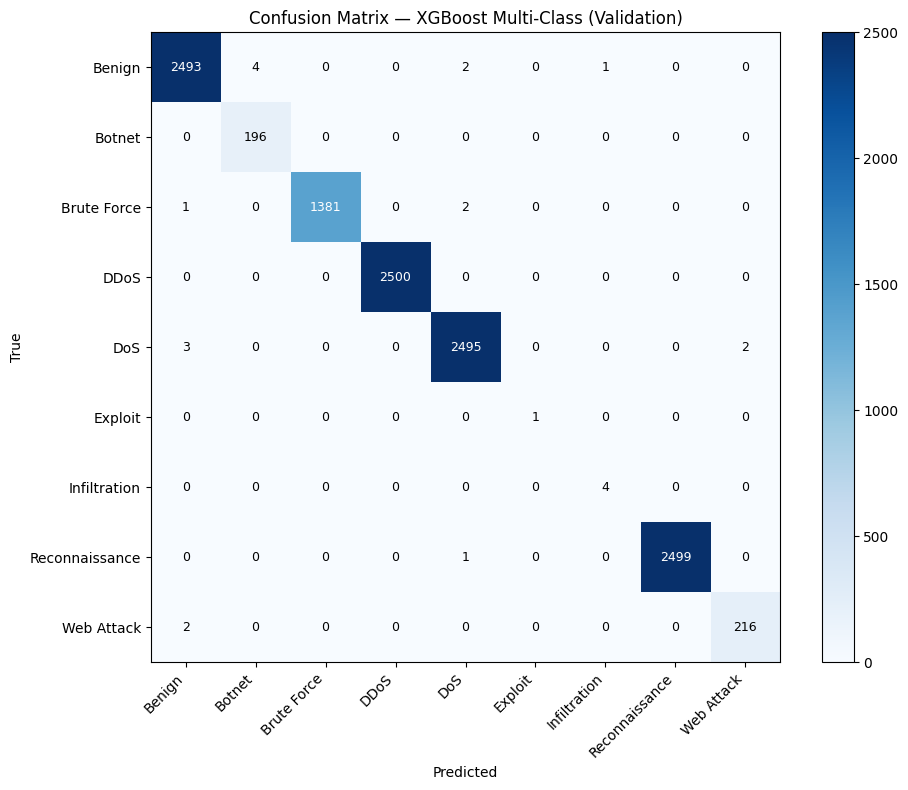

In [4]:
import matplotlib.pyplot as plt
import numpy as np

cm = np.array(val_metrics["confusion_matrix"])
classes = val_metrics["class_names"]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")

# Annotate cells
for i in range(len(classes)):
    for j in range(len(classes)):
        # White text on dark cells, black on light
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=9)

ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — XGBoost Multi-Class (Validation)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [5]:
test_metrics = evaluate(model, le, X_test, y_test, "XGBoost (Test)")

print("=== TEST SET RESULTS ===")
print(f"  Accuracy:        {test_metrics['accuracy']}")
print(f"  Macro Precision: {test_metrics['macro_precision']}")
print(f"  Macro Recall:    {test_metrics['macro_recall']}")
print(f"  Macro F1:        {test_metrics['macro_f1']}")

print("\n=== PER-CLASS PERFORMANCE (Test) ===")
print(format_per_class_summary(test_metrics).to_string(index=False))

=== TEST SET RESULTS ===
  Accuracy:        0.9984
  Macro Precision: 0.9752
  Macro Recall:    0.9506
  Macro F1:        0.9608

=== PER-CLASS PERFORMANCE (Test) ===
         Class  Support  Precision  Recall     F1
        Benign     5000     0.9962  0.9968 0.9965
           DoS     5000     0.9990  0.9980 0.9985
          DDoS     5000     0.9998  0.9996 0.9997
Reconnaissance     5000     0.9992  0.9998 0.9995
   Brute Force     2767     0.9996  0.9993 0.9995
    Web Attack      436     0.9954  0.9977 0.9966
        Botnet      394     0.9874  0.9924 0.9899
  Infiltration        7     0.8000  0.5714 0.6667
       Exploit        2     1.0000  1.0000 1.0000


In [6]:
print("=== INVESTIGATION: TINY CLASSES (Infiltration & Exploit) ===\n")

# How did Infiltration and Exploit do?
for tiny_class in ["Infiltration", "Exploit"]:
    test_idx = np.where(y_test == tiny_class)[0]
    if len(test_idx) == 0:
        print(f"{tiny_class}: not present in test set")
        continue

    X_tiny = X_test.iloc[test_idx]
    y_pred = model.predict(X_tiny)
    y_pred_str = le.inverse_transform(y_pred)

    correct = (y_pred_str == tiny_class).sum()
    total = len(y_pred_str)
    print(f"{tiny_class}: {correct}/{total} correct")
    print(f"  Predictions: {pd.Series(y_pred_str).value_counts().to_dict()}")
    print()

=== INVESTIGATION: TINY CLASSES (Infiltration & Exploit) ===

Infiltration: 4/7 correct
  Predictions: {'Infiltration': 4, 'Benign': 2, 'Botnet': 1}

Exploit: 2/2 correct
  Predictions: {'Exploit': 2}



=== Top 20 Features (XGBoost Multi-Class) ===
           feature  importance
   bwd_pkt_len_max    0.120833
         idle_mean    0.097469
   bwd_pkt_len_min    0.097395
    psh_flag_count    0.092148
  fwd_pkt_len_mean    0.071542
     fwd_psh_flags    0.070118
  min_seg_size_fwd    0.041741
  bwd_pkts_per_sec    0.031753
          idle_std    0.031600
 total_fwd_packets    0.031581
       bwd_iat_std    0.027514
       pkt_len_min    0.026746
  bwd_pkt_len_mean    0.022816
 fwd_header_length    0.022231
       bwd_iat_min    0.021035
   bwd_pkt_len_std    0.018641
      flow_iat_max    0.017874
init_win_bytes_bwd    0.015506
    urg_flag_count    0.014563
  act_data_pkt_fwd    0.013027


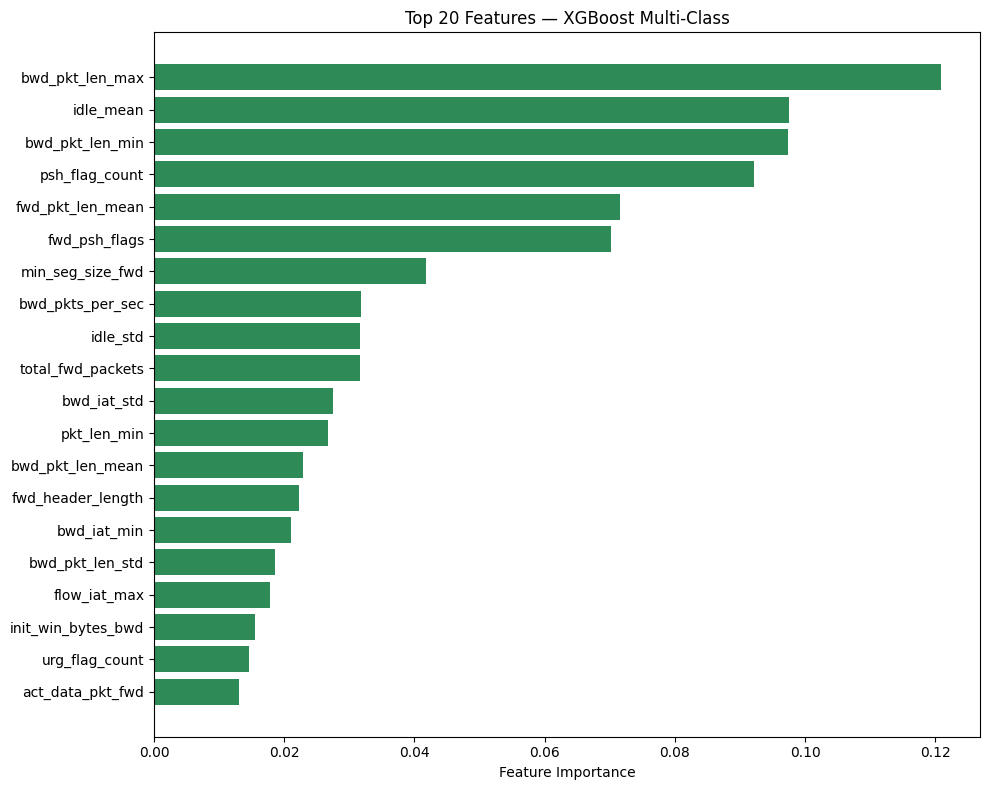

In [7]:
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False).head(20)

print("=== Top 20 Features (XGBoost Multi-Class) ===")
print(importances.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importances["feature"], importances["importance"], color="seagreen")
ax.invert_yaxis()
ax.set_xlabel("Feature Importance")
ax.set_title("Top 20 Features — XGBoost Multi-Class")
plt.tight_layout()
plt.show()

In [8]:
metadata = {
    "model_type": "XGBoost",
    "objective": "multi:softprob",
    "n_classes": len(le.classes_),
    "classes": list(le.classes_),
    "n_estimators": 200,
    "max_depth": 8,
    "learning_rate": 0.1,
    "training_set_size": len(X_train),
    "sample_weights": "balanced",
    "test_accuracy": test_metrics["accuracy"],
    "test_macro_f1": test_metrics["macro_f1"],
    "feature_count": X_train.shape[1],
}

path = save_model(model, le, name="xgb_multiclass_v1", metadata=metadata)
print(f"\n✅ Saved to: {path}")
print(f"   Size: {path.stat().st_size / 1e6:.2f} MB")

20:53:11 | Model saved: C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\models\xgb_multiclass_v1.joblib



✅ Saved to: C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\models\xgb_multiclass_v1.joblib
   Size: 3.30 MB
